# ⚡ Advanced Darkroom: Flashing the Paper (Pre-Flashing)

### Welcome, Master Printers!
Some negatives are incredibly difficult to print, such as night photographs with a very long exposure range or images suffering from reciprocity failure[cite: 5]. When there are light sources in the photograph, ordinary dodging and burning can be extremely demanding or even impossible[cite: 5].

Usually, photographers attempt to solve this by lowering the paper grade or using a lower filter grade to reduce the print contrast[cite: 5]. However, there is a better method for these seemingly futile cases: preexposing the print, which is also called flashing or preflashing[cite: 5]. 

*(Note: While flashing can also be used on film to increase the effective film speed, doing so requires an extraordinary effort; it is much easier to use flashing in the darkroom to enhance your normal printing procedures[cite: 5].)*

## Step 1: The Physics of the Exposure Threshold

To understand why flashing works, we must look at how photographic paper responds to light. 

* Very low levels of light will not actually expose the paper[cite: 5].
* The "exposure threshold" is the exact point where there is just enough light to produce a minimum print density[cite: 5]. 
* If this light is nonimage light (raw light without a negative), going past this threshold results in fogged paper[cite: 5].

**The Magic of the Flash:**
The trick is to expose the print to raw light *just below* this exposure threshold[cite: 5]. By getting the paper close to the threshold, any additional exposure from the enlarger pushes it over the threshold and creates density on the print[cite: 5]. 

This allows the dense highlights on your negative to produce tonality in the final print without adversely affecting the shadow areas[cite: 5]. It effectively reduces the apparent contrast better than simply lowering the paper grade[cite: 5].

Let's use Python to visualize this concept of the "Exposure Threshold"!

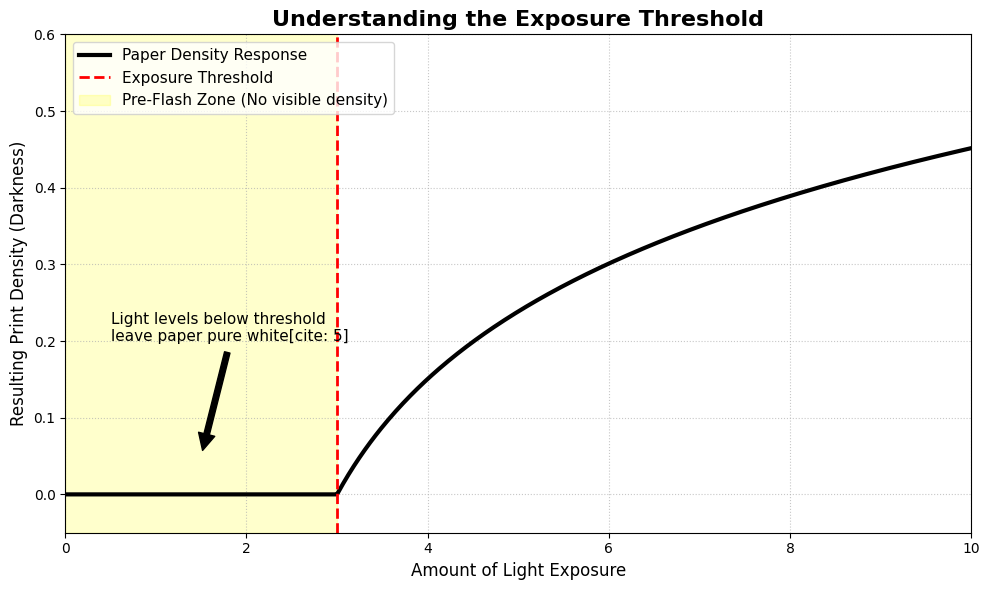

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_exposure_threshold():
    """
    Simulates the 'inertia' or 'threshold' of photographic paper.
    Demonstrates how very low levels of light do not create density until the threshold is crossed.
    """
    # Light exposure units hitting the paper
    exposure = np.linspace(0, 10, 500)
    
    # Paper density response: 0 until threshold, then starts climbing
    threshold = 3.0
    density = np.zeros_like(exposure)
    density[exposure > threshold] = 0.5 * np.log10(exposure[exposure > threshold] - threshold + 1)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(exposure, density, 'k-', lw=3, label="Paper Density Response")
    plt.axvline(x=threshold, color='r', linestyle='--', lw=2, label="Exposure Threshold")
    
    # Highlight the "Pre-Flash Zone"
    plt.axvspan(0, threshold, color='yellow', alpha=0.2, label="Pre-Flash Zone (No visible density)")
    
    plt.title("Understanding the Exposure Threshold", fontsize=16, fontweight='bold')
    plt.xlabel("Amount of Light Exposure", fontsize=12)
    plt.ylabel("Resulting Print Density (Darkness)", fontsize=12)
    
    plt.annotate("Light levels below threshold\nleave paper pure white[cite: 5]", 
                 xy=(1.5, 0.05), xytext=(0.5, 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)
    
    plt.xlim(0, 10)
    plt.ylim(-0.05, 0.6)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper left', fontsize=11)
    
    plt.tight_layout()
    plt.show()

simulate_exposure_threshold()

## Step 2: The "Free Lunch" of Contrast Control

Why not just use a softer contrast filter? Lowering the paper grade forces all the tones in the image closer together, making the whole image look flat. 

Flashing, however, acts as a "free lunch" because it does not drive the other tones closer together[cite: 5]. The relationships between the other tones, such as the midtones to the shadows, do not change[cite: 5]. It acts as if the greatest highlight densities on the negative were simply reduced slightly[cite: 5].

### The Laboratory Procedure: How to Flash
While there are many techniques for flashing (such as using a low-wattage bulb or a diffusion screen), using the enlarger itself offers the best accuracy, consistency, and repeatability[cite: 5].

* **Find the Threshold:** Remove the negative carrier and change the aperture, ensuring the enlarger is at the exact same height used for your print exposure[cite: 5]. Test the paper at one-second intervals using the smallest aperture[cite: 5]. You are looking for the first interval that produces a tone slightly darker than the white of the paper[cite: 5].
* **Set the Flash Time:** Your flashing exposure is the time *right below* that threshold[cite: 5]. For example, if f/45 at 5 seconds shows tonality, you will flash the paper at f/45 at 4 seconds[cite: 5]. *(Tip: If you cannot get below the threshold even at your minimum aperture, try adding a #2 contrast filter or a neutral density filter[cite: 5].)*
* **Make the Print:** After flashing the paper, put the negative carrier back in[cite: 5]. Cover the image area with thick cardboard to line up the negative and easel, then reset the aperture and timer to your previously determined maximum black settings and make the exposure[cite: 5].

* **An Alternative Formula:** The author provides a consistent starting formula based on the maximum black exposure: close the aperture down two stops and preexpose at 10 percent of the time[cite: 5]. For example, if maximum black is f/8 at 8 seconds, flash the paper at f/16 for 0.8 seconds (this requires an electronic timer)[cite: 5].

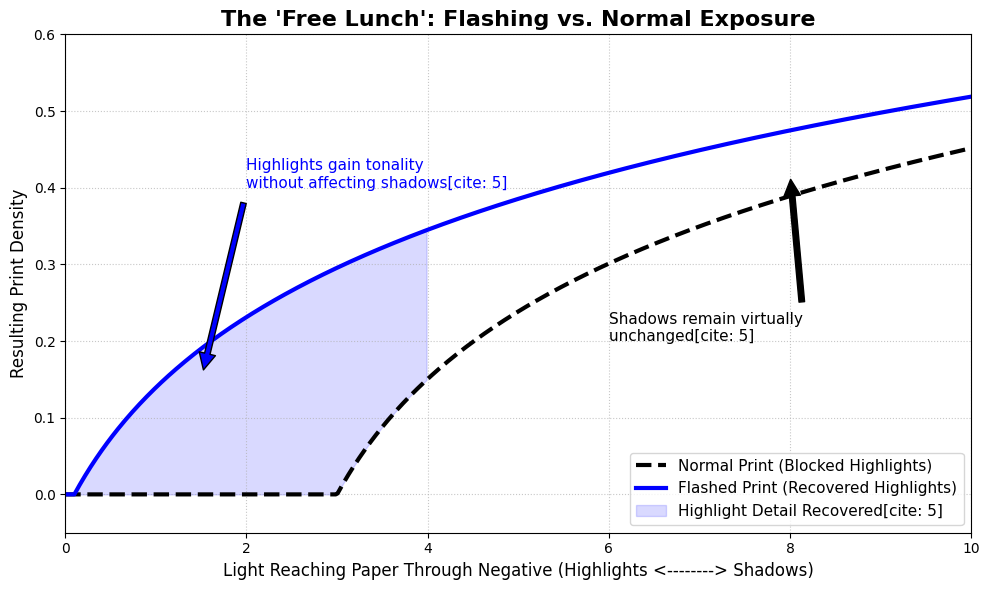

In [2]:
def simulate_the_free_lunch():
    """
    Simulates why flashing is a 'free lunch' compared to lowering contrast grades.
    It lifts the highlights without altering the shadow/midtone relationships.
    """
    # Simulate light transmitted through the negative (0 = Shadows, 10 = Dense Highlights)
    # The negative's highlights let almost no light through (0 exposure units)
    # The negative's shadows let a lot of light through (10 exposure units)
    light_from_enlarger = np.linspace(0, 10, 500)
    
    threshold = 3.0
    
    # 1. Normal Print (No Flash)
    normal_density = np.zeros_like(light_from_enlarger)
    normal_density[light_from_enlarger > threshold] = 0.5 * np.log10(light_from_enlarger[light_from_enlarger > threshold] - threshold + 1)
    
    # 2. Flashed Print 
    # We add a constant flash of light exactly at the threshold (e.g., +3.0 units)
    flash_amount = 2.9 # Just below threshold
    total_light = light_from_enlarger + flash_amount
    
    flashed_density = np.zeros_like(total_light)
    flashed_density[total_light > threshold] = 0.5 * np.log10(total_light[total_light > threshold] - threshold + 1)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(light_from_enlarger, normal_density, 'k--', lw=3, label="Normal Print (Blocked Highlights)")
    plt.plot(light_from_enlarger, flashed_density, 'b-', lw=3, label="Flashed Print (Recovered Highlights)")
    
    # Shade the area of improvement
    plt.fill_between(light_from_enlarger, normal_density, flashed_density, 
                    where=(light_from_enlarger < 4), 
                    color='blue', alpha=0.15, label="Highlight Detail Recovered[cite: 5]")
    
    plt.title("The 'Free Lunch': Flashing vs. Normal Exposure", fontsize=16, fontweight='bold')
    plt.xlabel("Light Reaching Paper Through Negative (Highlights <--------> Shadows)", fontsize=12)
    plt.ylabel("Resulting Print Density", fontsize=12)
    
    plt.annotate("Highlights gain tonality\nwithout affecting shadows[cite: 5]", 
                 xy=(1.5, 0.15), xytext=(2.0, 0.4),
                 arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=11, color='blue')
    
    plt.annotate("Shadows remain virtually\nunchanged[cite: 5]", 
                 xy=(8.0, 0.42), xytext=(6.0, 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)
    
    plt.xlim(0, 10)
    plt.ylim(-0.05, 0.6)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

simulate_the_free_lunch()